## Importar los datos

In [11]:
import polars as pl
import pandas as pd

ruta_archivo = 'data/raw/tomtom_move_reports/segments_1_to_31_aug_2024.parquet'
df_lazy_original = pl.scan_parquet(ruta_archivo)



In [12]:
columnas_finales = [
    "station_name", 
    "date", 
    "segment_id", 
    "street_name", 
    "hour_start", 
    "hour_end", 
    "travel_time_ratio",
    "sample_size",
    "frc",
    "harmonic_avg_speed",  # Añade esto
    "distance_m",          # Añade esto
    "travel_time_std"      # Añade esto
]


## ¿Cuántas calles hay en el radio de una estación?

In [13]:
df_plan_conteo = (
    df_lazy_original
    .select(columnas_finales)

    .filter(
        (pl.col("station_name") == "SURESTE") 
    )
    .select([
        
        pl.col("segment_id").n_unique().alias("total_segmentos_distintos"),
        pl.col("street_name").n_unique().alias("total_calles_distintas"),
        pl.len().alias("total_reportes")
    ])
)

df_conteo = df_plan_conteo.collect()
df_conteo

total_segmentos_distintos,total_calles_distintas,total_reportes
u32,u32,u32
11243,845,8364792


### Nueva base de datos: CENTRO

In [14]:

#minimo 10 carros, frc maximo de 4 (las calles principales están usalmente entre 0-3)
MIN_SAMPLE_SIZE = 10
MAX_FRC_PRINCIPAL = 4

df_estacion = (
    df_lazy_original

    .filter(
        (pl.col("station_name") == "SURESTE") 
        & (pl.col("frc") <= MAX_FRC_PRINCIPAL) 
        & (pl.col("sample_size") >= MIN_SAMPLE_SIZE)
    )
    .select(columnas_finales)
    .group_by(["station_name", "street_name", "hour_start", "date"])
    
    .agg([

        (
            pl.col("harmonic_avg_speed").mul(pl.col("distance_m")).sum()
            / pl.col("distance_m").sum()
        ).alias("weighted_harmonic_speed"), 
        
        pl.col("travel_time_ratio").mean().alias("avg_tti_street"),
        pl.col("sample_size").sum().alias("total_sample_size"),
        pl.col("travel_time_std").mean().alias("avg_travel_time_std")
    
    ])
    
    .sort(["date", "station_name", "street_name","hour_start"])

)

df_estacion_collected = df_estacion.collect()
df_estacion_pd = df_estacion_collected.to_pandas()
df_estacion_pd.to_csv('data/processed/df_sureste.csv', index=False)


In [15]:
df_estacion.head().collect()

station_name,street_name,hour_start,date,weighted_harmonic_speed,avg_tti_street,total_sample_size,avg_travel_time_std
str,str,i64,str,f64,f64,i64,f64
"""SURESTE""",null,7,"""2024-08-01""",4.2,12.02,16,111.73
"""SURESTE""",null,8,"""2024-08-01""",23.953256,6.656,60,17.04
"""SURESTE""",null,9,"""2024-08-01""",2.4,21.49,15,89.63
"""SURESTE""",null,10,"""2024-08-01""",6.600163,5.015,23,44.685
"""SURESTE""",null,11,"""2024-08-01""",24.06117,7.153333,33,22.456667


In [16]:
# Imprime dimensiones de df_estacion (usar el DataFrame ya colectado)
print(f"Filas: {df_estacion_pd.shape[0]}, Columnas: {df_estacion_pd.shape[1]}")


Filas: 10513, Columnas: 8


### Variables disponibles

["station_name", "date", "segment_id", "new_segment_id", "frc", "street_name", "distance_m", "time_set_id", "hour_start", "hour_end", "harmonic_avg_speed", "median_speed", "avg_speed", "std_speed", "travel_time_std", "sample_size", "normalized_sample_size", "avg_travel_time", "median_travel_time", "travel_time_ratio", "speed_percentiles", "geometry_wkt"]


columnas: ["station_name", "date", "segment_id", "street_name", "hour_start", "hour_end", "travel_time_ratio"]

## EDA?

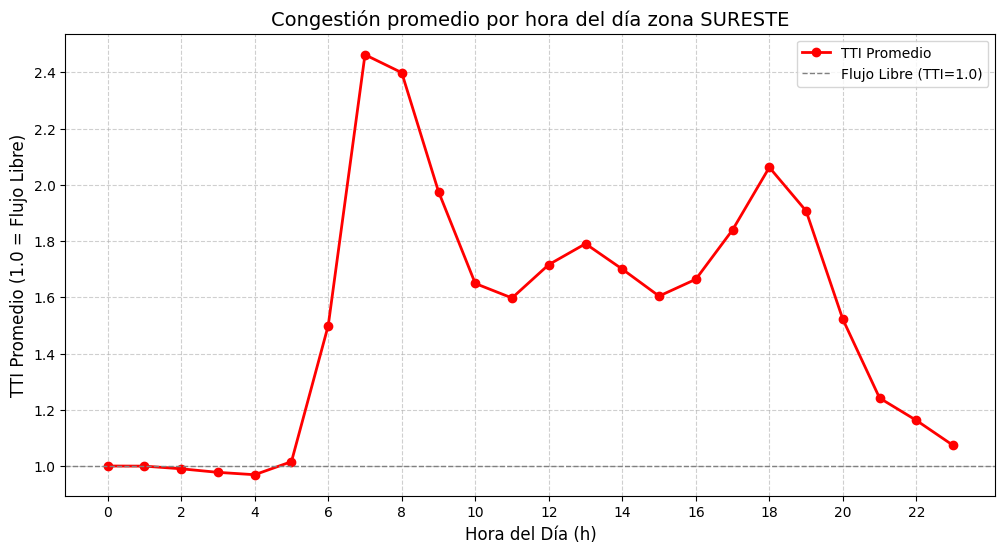

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar el archivo CSV asumiendo que el encabezado está en la primera fila
df = pd.read_csv('data/processed/df_sureste.csv')

# Renombrar columnas según la estructura inferida de la agregación:
df.rename(columns={
    '2': 'hour_start',
    '3': 'date',
    '4': 'avg_speed_street', # Velocidad
    '5': 'avg_tti_street',   # TTI (Congestión)
    '6': 'total_sample_size' # Volumen de Tráfico
}, inplace=True)

# Eliminar columnas irrelevantes/vacías
df.drop(columns=['1'], errors='ignore', inplace=True)

# Conversión de Tipos de Datos
df['date'] = pd.to_datetime(df['date'])
df['hour_start'] = df['hour_start'].astype(int)

# --- GRÁFICA 1: TTI promedio por hora del día (Congestión) ---
tti_hourly = df.groupby('hour_start')['avg_tti_street'].mean().reset_index()

# --- GRÁFICA 2: Volumen de tráfico por día de la semana ---
df['day_of_week'] = df['date'].dt.day_name()
# Mapeo de días a español
day_mapping = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df['day_of_week'] = df['day_of_week'].map(day_mapping)
day_order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
traffic_daily = df.groupby('day_of_week')['total_sample_size'].sum().reindex(day_order).reset_index()


# --- Creación de Gráficas ---
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

# TTI (Línea)
# Ensure axes is indexable (plt.subplots(1,1,...) returns a single Axes)
if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

# Plot TTI
axes[0].plot(
    tti_hourly['hour_start'],
    tti_hourly['avg_tti_street'],
    marker='o',
    color='red',
    linewidth=2,
    markersize=6,
    label='TTI Promedio'
)
axes[0].set_title('Congestión promedio por hora del día zona SURESTE', fontsize=14)
axes[0].set_xlabel('Hora del Día (h)', fontsize=12)
axes[0].set_ylabel('TTI Promedio (1.0 = Flujo Libre)', fontsize=12)
axes[0].set_xticks(np.arange(0, 24, 2))
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Flujo Libre (TTI=1.0)')
axes[0].legend()


plt.savefig('reports/images/trafico_sureste.png')


C:\Users\90480\AppData\Local\Temp\ipykernel_22240\2208199058.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


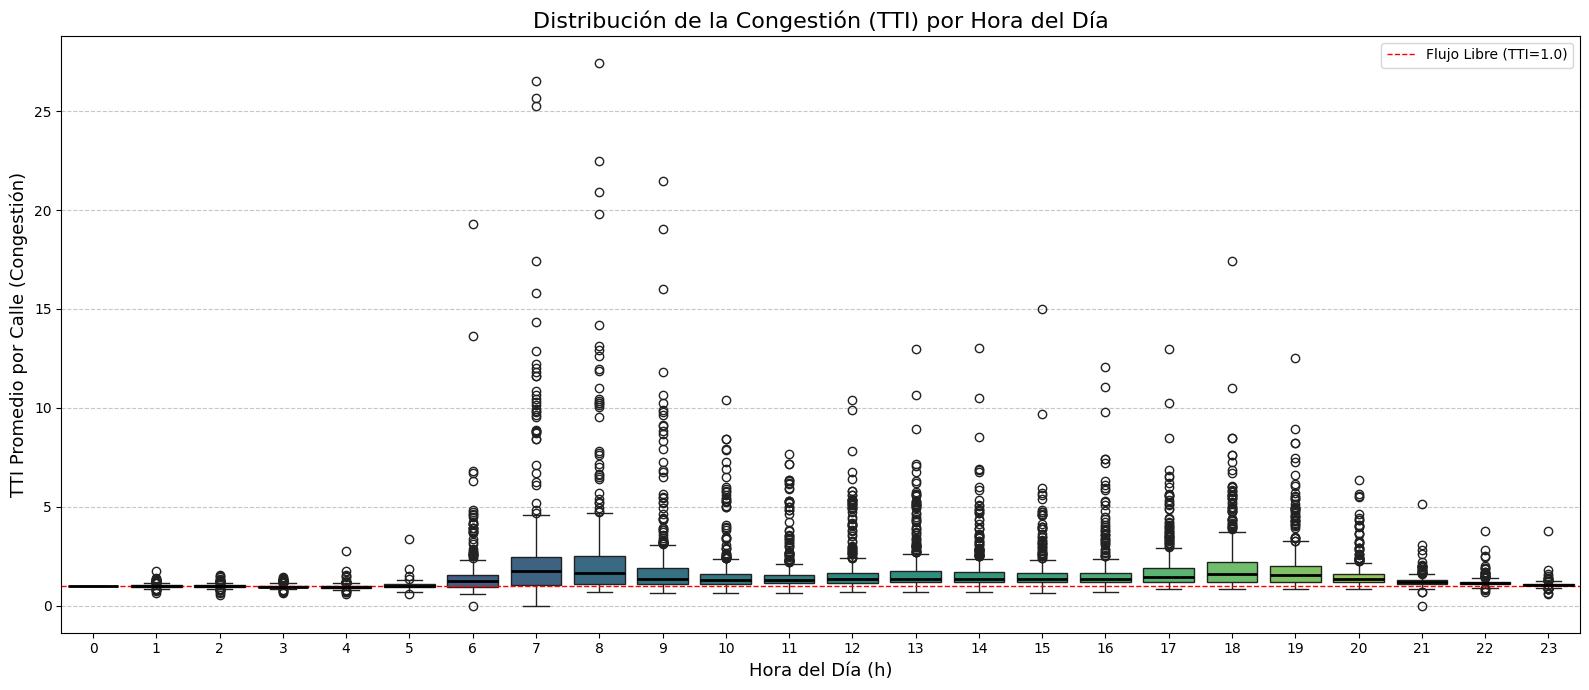

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ... Código de carga y limpieza de datos ...

# --- Creación del Box Plot con estilo visual ajustado ---
plt.figure(figsize=(16, 7))

sns.boxplot(
    x='hour_start', 
    y='avg_tti_street', 
    data=df, 
    palette='viridis', # Paleta de colores para mejor diferenciación visual
    notch=False,
    medianprops={'color': 'black', 'linewidth': 2} 
)

plt.title('Distribución de la Congestión (TTI) por Hora del Día', fontsize=16)
plt.xlabel('Hora del Día (h)', fontsize=13)
plt.ylabel('TTI Promedio por Calle (Congestión)', fontsize=13)
plt.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Flujo Libre (TTI=1.0)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.savefig('tti_box_plot_por_hora_ajustado.png')

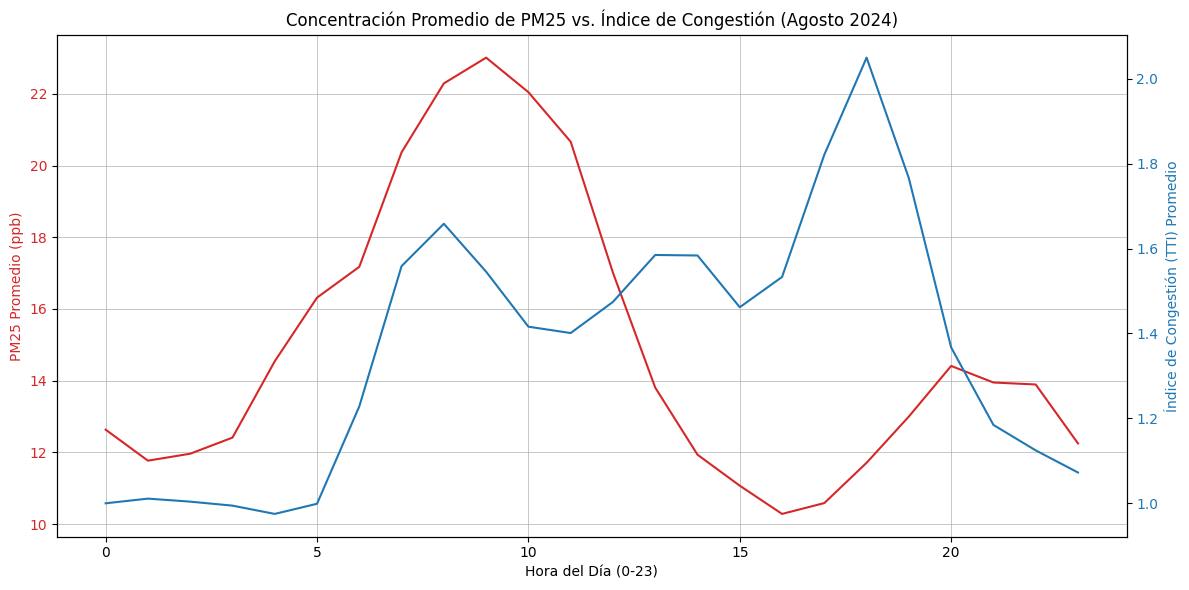

In [21]:
import pandas as pd
import matplotlib.pyplot as plt


df_contaminantes = pd.read_csv('data/processed/agosto2024.csv')
df_trafico = pd.read_csv('data/processed/df_todo.csv')
df_contaminantes.columns = ['CO', 'contaminante', 'NO', 'NO2', 'PM2.5', 'PM25', 'PM10', 'SO2', 'WDR', 'WSR', 'Zona', 'Hora']

# Convertir la columna 'Hora' a numérica si no lo está (es crucial)
df_contaminantes['Hora'] = pd.to_numeric(df_contaminantes['Hora'])
df_trafico['hour_start'] = pd.to_numeric(df_trafico['hour_start'])


## --- 2. Preparación de Contaminantes (PM25) ---
# Calcular el promedio de PM25 por hora
df_PM25_promedio = df_contaminantes.groupby('Hora')['PM25'].mean().reset_index()
df_PM25_promedio.rename(columns={'PM25': 'PM25_Promedio'}, inplace=True)


## --- 3. Preparación de Tráfico (avg_tti_street) ---
# Calcular el promedio de avg_tti_street (Índice de Congestión) por hora
df_trafico_promedio = df_trafico.groupby('hour_start')['avg_tti_street'].mean().reset_index()
df_trafico_promedio.rename(columns={'hour_start': 'Hora', 'avg_tti_street': 'Congestion_Promedio'}, inplace=True)


## --- 4. Combinación de Datos ---
# Unir los dos promedios en un solo DataFrame
df_final = pd.merge(df_PM25_promedio, df_trafico_promedio, on='Hora', how='inner')


## --- 5. Visualización con Doble Eje Y (Crucial para diferentes escalas) ---

fig, ax1 = plt.subplots(figsize=(12, 6))

# Primer Eje Y: PM25 (Línea Roja para mantener consistencia con la gráfica original de PM25 2024)
color = 'tab:red'
ax1.set_xlabel('Hora del Día (0-23)')
ax1.set_ylabel('PM25 Promedio (ppb)', color=color)
ax1.plot(df_final['Hora'], df_final['PM25_Promedio'], color=color, linestyle='-')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='-', linewidth=0.5)

# Crear un segundo eje Y que comparte el mismo eje X
ax2 = ax1.twinx()  
color = 'tab:blue' # Usaremos azul para el tráfico/congestión
ax2.set_ylabel('Índice de Congestión (TTI) Promedio', color=color)  
ax2.plot(df_final['Hora'], df_final['Congestion_Promedio'], color=color, linestyle='-')
ax2.tick_params(axis='y', labelcolor=color)

# Título y Leyenda
plt.title('Concentración Promedio de PM25 vs. Índice de Congestión (Agosto 2024)')
fig.tight_layout() # Asegura que no se superpongan elementos
plt.show()



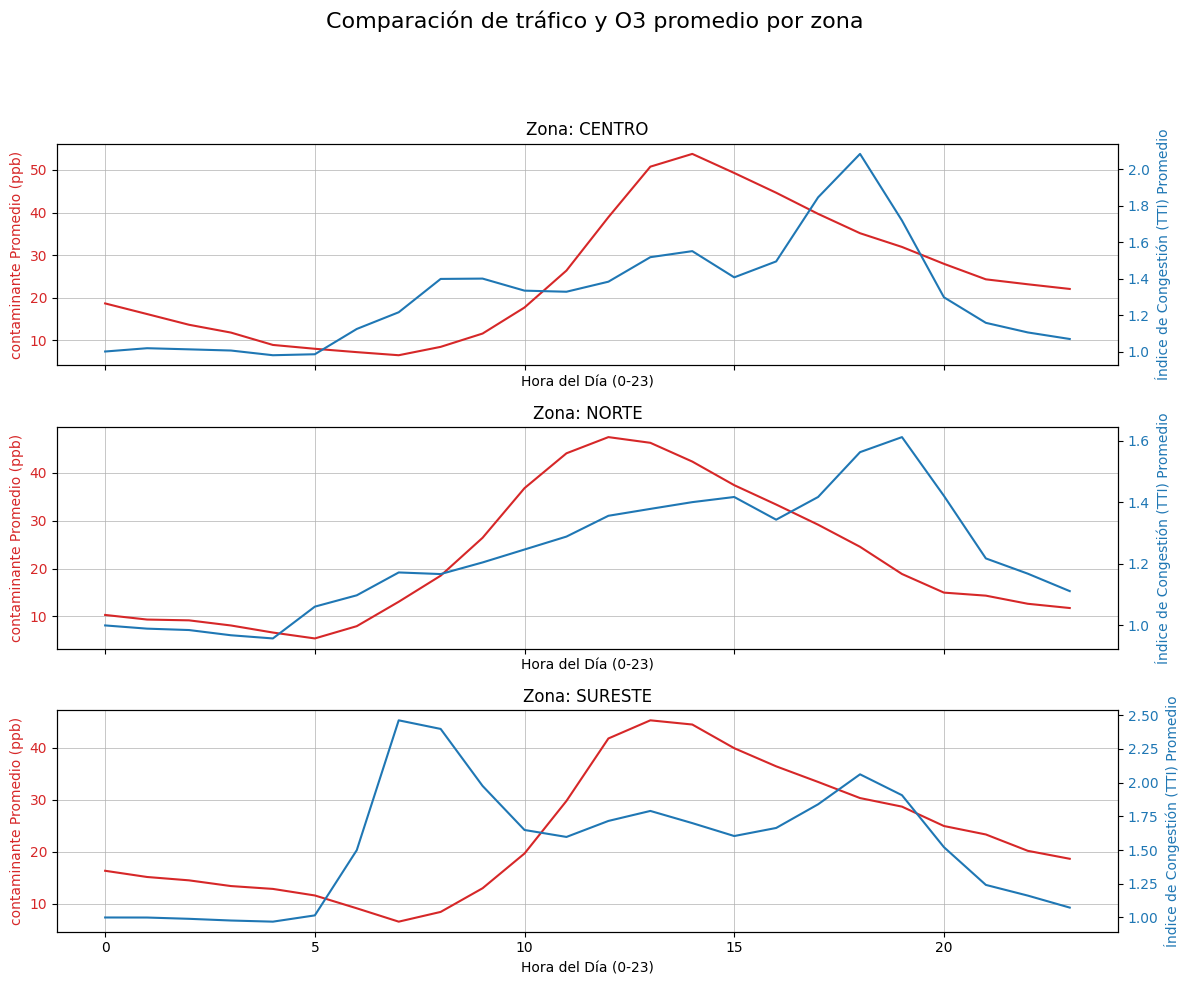

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

contaminante = "O3"

# Cargar datos
df_trafico_todo = pd.read_csv('data/processed/df_todo.csv')
df_contaminantes_todo = pd.read_csv('data/processed/agosto2024.csv')

# Normalizar columnas de zona y hora en contaminantes

pcol = f"{contaminante}"
df_contaminantes_todo["Hora"] = pd.to_numeric(df_contaminantes_todo["Hora"], errors='coerce')
df_trafico_todo['hour_start'] = pd.to_numeric(df_trafico_todo['hour_start'], errors='coerce')
zonas = pd.Series(df_trafico_todo['station_name'].dropna().unique()).tolist()[:3]


# Crear figura con 3 subplots (3 filas, 1 columna)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle(f'Comparación de tráfico y {contaminante} promedio por zona', fontsize=16)
fig.subplots_adjust(hspace=0.6, top=0.92)

for idx, zona in enumerate(zonas):

    # Filtrar tráfico por zona
    df_trafico_zona = df_trafico_todo[df_trafico_todo['station_name'] == zona].copy()
    df_trafico_promedio = (
        df_trafico_zona.dropna(subset=['hour_start'])
        .groupby('hour_start', as_index=False)['avg_tti_street']
        .mean()
    )
    df_trafico_promedio.rename(columns={'hour_start': 'Hora', 'avg_tti_street': 'Congestion_Promedio', 'PM2.5': 'PM25'}, inplace=True)
    df_contaminantes_todo.rename(columns={'PM2.5': 'PM25'}, inplace=True)

    # Filtrar contaminantes por zona (buscar columna de zona encontrada)
    df_contam_zona = df_contaminantes_todo.loc[df_contaminantes_todo["Zona"].astype(str).str.upper() == str(zona).upper()].copy()
    df_contam_zona["Hora"] = pd.to_numeric(df_contam_zona["Hora"], errors='coerce')


    df_contaminante_promedio = (
        df_contam_zona.dropna(subset=['Hora'])
        .groupby('Hora', as_index=False)[pcol]
        .mean()
        .rename(columns={pcol: 'contaminantePromedio'})
    )

    # Merge por 'Hora'
    df_final = pd.merge(df_contaminante_promedio, df_trafico_promedio, on='Hora', how='inner')

    # Plotear en el subplot correspondiente
    ax1 = axes[idx]
    color = 'tab:red'
    ax1.set_xlabel('Hora del Día (0-23)')
    ax1.set_ylabel('contaminante Promedio (ppb)', color=color)
    ax1.plot(df_final['Hora'], df_final['contaminantePromedio'], color=color, linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, which='both', linestyle='-', linewidth=0.5)

    # Segundo eje Y
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Índice de Congestión (TTI) Promedio', color=color)
    ax2.plot(df_final['Hora'], df_final['Congestion_Promedio'], color=color, linestyle='-')
    ax2.tick_params(axis='y', labelcolor=color)

    ax1.set_title(f'Zona: {zona}')

# Guardar y mostrar
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(f'reports/images/comparativo_{contaminante}_zonas.png', dpi=300, bbox_inches='tight')
plt.show()
